# K-Nearest Neighbors on Personal Transaction Data

Brianna Sengchan

## Imports & Data Loading

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

In [2]:
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("number of features:", len(feature_cols))
print("number of classes:", y_train.nunique())

train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)
number of features: 12
number of classes: 5


## Model Training & Evaluation

In [3]:
X_train

,Transaction Type,Day of Week,Month,Amount_scaled,Is_Weekend,Acct_Checking,Acct_Platinum Card,Acct_Silver Card,Amount_x_Transaction_Type,Amount_x_Acct_Checking,Amount_x_Acct_Platinum Card,Amount_x_Acct_Silver Card
3279,0,1,10,-0.110191,0,0,1,0,-0.000000,-0.000000,-0.110191,-0.000000
2882,0,2,3,-0.426278,0,0,1,0,-0.000000,-0.000000,-0.426278,-0.000000
3779,0,1,6,-0.199947,0,1,0,0,-0.000000,-0.199947,-0.000000,-0.000000
8962,0,5,3,-0.029880,1,0,1,0,-0.000000,-0.000000,-0.029880,-0.000000
8894,0,5,4,0.355848,1,0,0,1,0.000000,0.000000,0.000000,0.355848
...,...,...,...,...,...,...,...,...,...,...,...,...
1809,1,0,5,0.348292,0,1,0,0,0.348292,0.348292,0.000000,0.000000
2742,0,3,12,-0.541001,0,0,1,0,-0.000000,-0.000000,-0.541001,-0.000000
1467,1,4,3,0.228259,0,0,1,0,0.228259,0.000000,0.228259,0.000000
9075,0,1,5,-0.541052,0,0,1,0,-0.000000,-0.000000,-0.541052,-0.000000


In [4]:
# Checking the class distribution for data imbalance

class_distribution = y_train.value_counts()

print("Class distribution in training set:")
print(class_distribution)

print("\nClass distribution percentage:")
print((class_distribution / len(y_train) * 100).round(2))

Class distribution in training set:
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64

Class distribution percentage:
Category_Label
0    35.35
1    34.47
3    21.56
2     6.22
4     2.38
Name: count, dtype: float64


### Baseline Model

In [5]:
# KNN model
knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights = "uniform",
    metric = "minkowski",
    p=2
)

start_train = time.time()
knn.fit(X_train, y_train)
baseline_train_time = time.time() - start_train

start_pred = time.time()
baseline_pred = knn.predict(X_test)
baseline_pred_time = time.time() - start_pred
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")

# Print Results
print("Accuracy: ", accuracy_score(y_test, baseline_pred))
print("Weighted F1: ", f1_score(y_test, baseline_pred, average = "weighted", zero_division = 0))
print("Macro F1:", baseline_macro_f1)
print("Training Time: ", baseline_train_time)
print("Prediction TIme: ", baseline_pred_time)

Accuracy:  0.33996299722479184
Weighted F1:  0.3108139980470398
Macro F1: 0.20509846322786948
Training Time:  0.013543844223022461
Prediction TIme:  0.015716075897216797


In [6]:
# Baseline KNN Classification Report
baseline_report = classification_report(
    y_test,
    baseline_pred,
    zero_division=0,
    output_dict=True
)

baseline_report_df = pd.DataFrame(baseline_report).transpose()

baseline_report_df = baseline_report_df.rename(
    columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    }
)

baseline_report_df

,Precision,Recall,F1-Score,Support
0,0.359712,0.523560,0.426439,764.000000
1,0.346106,0.375839,0.360360,745.000000
2,0.347826,0.059259,0.101266,135.000000
3,0.215596,0.100858,0.137427,466.000000
4,0.000000,0.000000,0.000000,52.000000
accuracy,0.339963,0.339963,0.339963,0.339963
macro avg,0.253848,0.211903,0.205098,2162.000000
weighted avg,0.314567,0.339963,0.310814,2162.000000


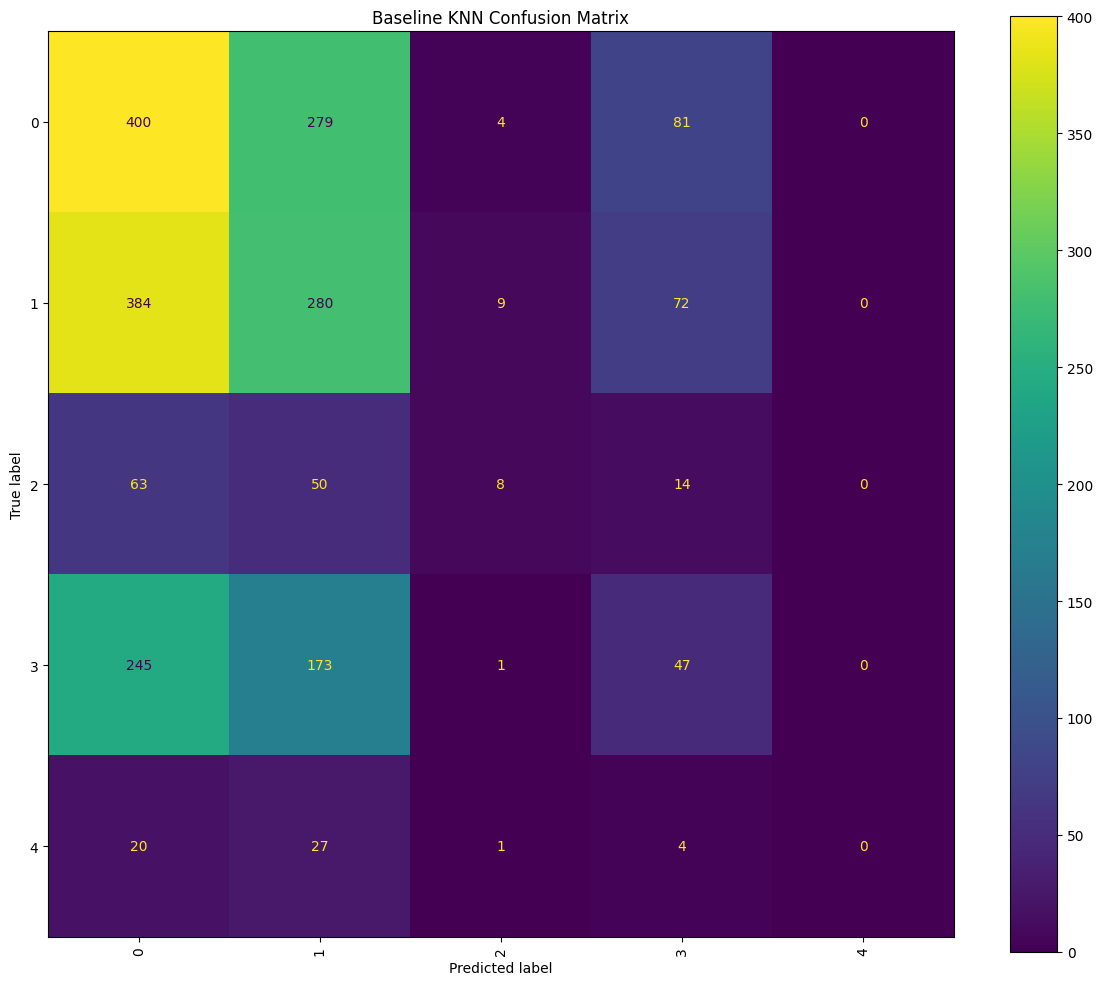

In [7]:
# Baseline KNN Confusion Matrix
labels = sorted(y_test.unique())

baseline_cm = confusion_matrix(y_test, baseline_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=labels
)

display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Baseline KNN Confusion Matrix")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [8]:
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsClassifier(
    metric = "minkowski",
    algorithm = "brute"
)

grid = GridSearchCV(
    estimator = knn,
    param_grid = param_grid,
    scoring = "f1_weighted",
    cv = 2,
    n_jobs = -1,
    verbose = 1
)

start_train = time.time()
grid.fit(X_train, y_train)
tuned_time = time.time() - start_train

# Print Results
print("Best Parameters: ", grid.best_params_)
print("Best Weighted F1: ", grid.best_score_)
print("Tuned Time: ", tuned_time)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters:  {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Best Weighted F1:  0.33032101178015794
Tuned Time:  3.7410478591918945


### Evaluation

In [9]:
# Tuned KNN
best_knn = grid.best_estimator_

start_pred = time.time()
tuned_pred = best_knn.predict(X_test)
tuned_pred_time = time.time() - start_pred

accuracy = accuracy_score(y_test, tuned_pred)
precision = precision_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
recall = recall_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
f1 = f1_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
macro_f1 = f1_score(y_test, tuned_pred, average="macro", zero_division=0)

print("Best Parameters: ", grid.best_params_)
print("Accuracy: ", accuracy)
print("Weighted Precision: ", precision)
print("Weighted Recall: ", recall)
print("Weighted F1: ", f1)
print("Macro F1: ", macro_f1)
print("Prediction Time: ", tuned_pred_time)

Best Parameters:  {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Accuracy:  0.34875115633672527
Weighted Precision:  0.33038636073454447
Weighted Recall:  0.34875115633672527
Weighted F1:  0.32079269121106985
Macro F1:  0.21069661112918786
Prediction Time:  1.4129374027252197


In [10]:
# Tuned KNN Classification Report
tuned_report = classification_report(
    y_test,
    tuned_pred,
    zero_division=0,
    output_dict=True
)

tuned_report_df = pd.DataFrame(tuned_report).transpose()

tuned_report_df = tuned_report_df.rename(
    columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    }
)

tuned_report_df

,Precision,Recall,F1-Score,Support
0,0.373823,0.519634,0.434830,764.000000
1,0.350711,0.397315,0.372561,745.000000
2,0.466667,0.051852,0.093333,135.000000
3,0.224066,0.115880,0.152758,466.000000
4,0.000000,0.000000,0.000000,52.000000
accuracy,0.348751,0.348751,0.348751,0.348751
macro avg,0.283053,0.216936,0.210697,2162.000000
weighted avg,0.330386,0.348751,0.320793,2162.000000


In [11]:
# Checking Per-Class Accuracy

labels = sorted(y_test.unique())

tuned_cm = confusion_matrix(y_test, tuned_pred, labels=labels)

tuned_class_accuracy = tuned_cm.diagonal() / tuned_cm.sum(axis=1)

tuned_class_accuracy_df = pd.DataFrame({
    "Class": labels,
    "Accuracy": tuned_class_accuracy
})

tuned_class_accuracy_df

,Class,Accuracy
0,0,0.519634
1,1,0.397315
2,2,0.051852
3,3,0.115880
4,4,0.000000


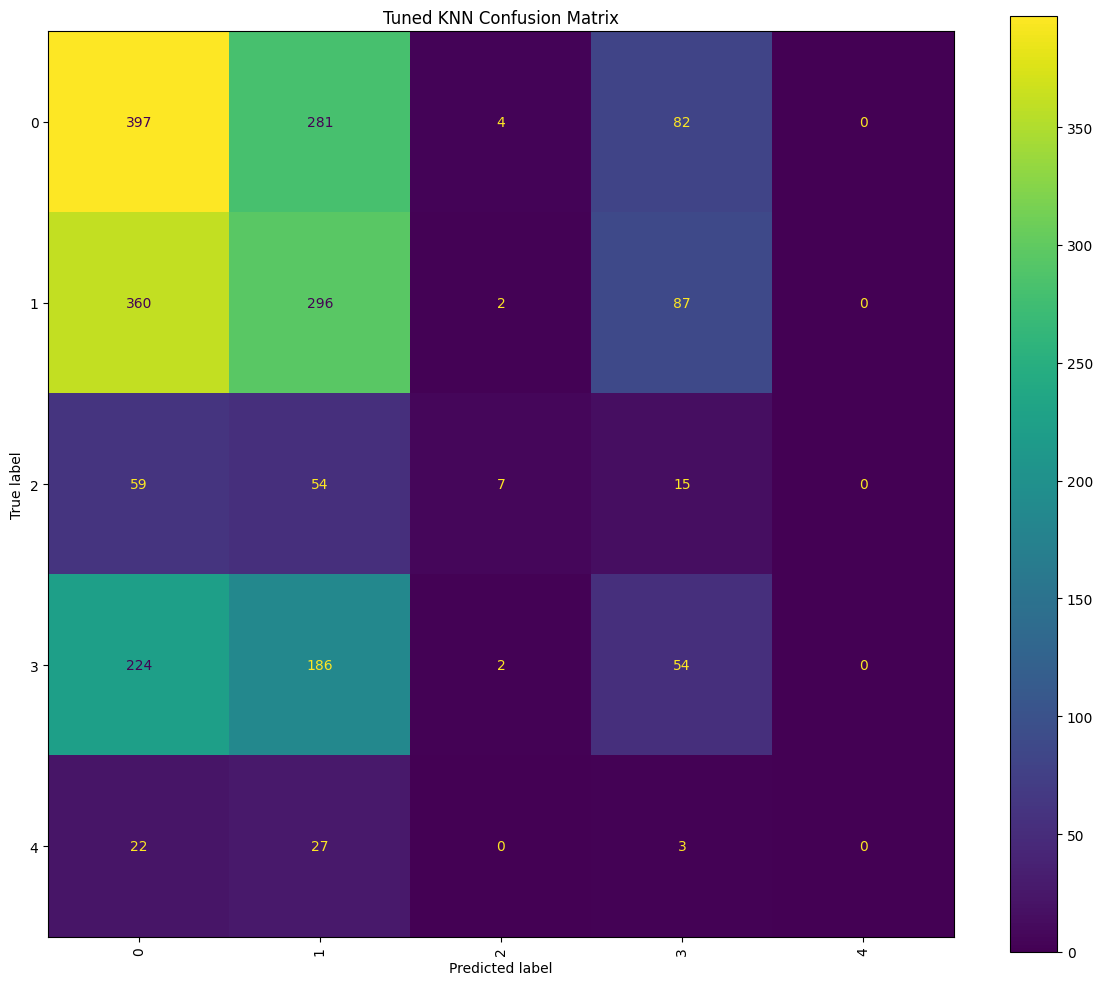

In [12]:
# Tuned KNN Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=labels
)

display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Tuned KNN Confusion Matrix")
plt.tight_layout()
plt.show()